<a href="https://colab.research.google.com/github/tomasrodriguezr11/Programacion-MIAAD/blob/main/Practica20_266228.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 20 - Unidad 2: Ejercicios de EDA usando AirQuality**
**Programación para analítica descriptiva y predictiva MIAAD**

*Realizada por: Tomás Eduardo Rodríguez Ramírez*

*Número de matrícula: 266228*

**Instrucciones de la tarea: Análisis Exploratorio de Datos (EDA)**

**Objetivo**

Realizar un Análisis Exploratorio de Datos (EDA) aplicando técnicas estadísticas y de visualización para comprender la estructura, distribución y relaciones dentro de un conjunto de datos.

Utilza el archivo AirQuality que se proprociona

# **Entorno de trabajo**

La actividad debe realizarse obligatoriamente en Google Colab.

El notebook debe incluir:

- código en Python

- visualizaciones

- celdas de texto con interpretación de los resultados

Cada sección del análisis debe estar claramente documentada

# **Estructura que debe tener el Google Colab**

El notebook deberá estar organizado en las siguientes secciones.

# **1. Introducción del dataset**

Incluye una sección donde expliques:

- Nombre del dataset

- Fuente de donde fue obtenido

- Número de observaciones

- Número de variables

- Descripción de las variables

También debes mostrar:

- las primeras filas del dataset (head())

- la estructura del dataset (info())

# **2.  Exploración inicial de datos**

Realiza lo siguiente:

- Identificar valores faltantes

- Analizar tipos de variables

- Revisar posibles valores atípicos

- Mostrar estadísticas descriptivas básicas (describe())

Explica brevemente lo que observas.

# **3. Análisis univariado**

Analiza una variable individualmente.

Para variables numéricas, elige algunas de las siguientes herramientas:

- histogramas + KDE

- boxplot

Para variables categóricas, si existe, elige una de ellas incluye una de las siguientes herramientas (elige la que quieras):

- gráficas de barras

- gráficas de pastel

En cada gráfico debes interpretar brevemente los resultados.

# **4. Análisis bivariado**

Analiza relaciones entre dos variables. Elige las variables que gustes

**Numérica vs Numérica**

Utiliza:

- scatter plots

Explica qué relaciones observas.

# **5. Análisis multivariado**

Realiza análisis considerando múltiples variables.

Incluye: Mapa de Calor - Correlación entre variables

# **6. Identificación de patrones**

Con base en el análisis realizado, responde:

- ¿Qué patrones importantes encontraste?

- ¿Existen relaciones entre variables?

- ¿Se observan clusters naturales?

- ¿Existen outliers?

- ¿Qué variables parecen ser más relevantes?

# **Entregable**

Debes entregar: un archivo de txt con el link a tu cuaderno (con permisos de visualización) o repositorio en github

No olvides enviar tu enlace de github, el .ipynb y el pdf respondiendo a las preguntas derivadas del EDA

# **1. Introducción del dataset**

In [6]:
import pandas as pd
import numpy as np

dataset="drive/MyDrive/ProgramacionMIAAD/AirQuality.csv"
df = pd.read_csv(dataset, sep=';')
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- **Nombre del dataset:** AirQuality

- **Fuente de donde fue obtenido:** Dataset público del UCI Machine Learning Repository, utilizado para analizar la calidad del aire en una ciudad italiana mediante sensores químicos.

- **Número de observaciones:** 9471

- **Número de variables:** 13

- **Descripción de las variables:**
  - CO(GT) = Concentración real de Monóxido de Carbono

  - PT08.Sx = Respuesta de sensores químicos

  - NMHC(GT) = Hidrocarburos No Metano

  - C6H6(GT) = Benceno

  - NOx(GT) = Óxidos de nitrógeno

  - NO2(GT) = Concentración real de Dióxido de Nitrógeno

  - T = Temperatura

  - RH = Humedad relativa

  - AH = Humedad absoluta

In [7]:
# Se eliminan las columnas vacías
df = df.dropna(axis=1, how='all')

# Se reemplazan los valores faltantes codificados
df = df.replace(-200, np.nan)

# Conversión de variables con coma a decimal
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='ignore')

df.head()

/tmp/ipykernel_2331/11983224.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   NMHC(GT)       914 non-null    float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  8991 non-null   float64
 7   NOx(GT)        7718 non-null   float64
 8   PT08.S3(NOx)   8991 non-null   float64
 9   NO2(GT)        7715 non-null   float64
 10  PT08.S4(NO2)   8991 non-null   float64
 11  PT08.S5(O3)    8991 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


# **2.  Exploración inicial de datos**

In [12]:
# Identificación de valores faltantes
missing = df.isnull().sum().to_frame(name='Missing_Values')
missing['Percent'] = ((missing['Missing_Values'] / len(df)) * 100).round(0)
missing = missing.sort_values('Percent', ascending=False)
missing

,Missing_Values,Percent
NMHC(GT),8557,90.0
NO2(GT),1756,19.0
NOx(GT),1753,19.0
PT08.S4(NO2),480,5.0
PT08.S3(NOx),480,5.0
PT08.S1(CO),480,5.0
PT08.S2(NMHC),480,5.0
PT08.S5(O3),480,5.0
Date,114,1.0
Time,114,1.0


**Observaciones:**
- La variable NMHC(GT) tiene muchos valores faltantes (90%)
- También hay una cantidad considerable de valores faltantes en NOx(GT) y NO2(GT)
- Algunas variables como T, RH y AH tienen muy pocos faltantes (1%)

In [13]:
# Análisis de tipos de variables
df.dtypes

,0
Date,object
Time,object
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


**Observaciones:**
- La mayoría de variables del dataset son numéricas continuas, relacionadas con concentraciones de contaminantes y variables meteorológicas.

In [14]:
# Estadísticas descriptivas básicas (describe())
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,8991.000000,914.000000,9357.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1099.833166,218.811816,1.865683,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,9.778305,39.485380,-6.837604
std,77.657170,217.080037,204.459921,41.380206,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,43.203623,51.216145,38.976670
min,-200.000000,647.000000,7.000000,-200.000000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,937.000000,67.000000,4.000000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,10.900000,34.100000,0.692300
50%,1.500000,1063.000000,150.000000,7.900000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.200000,48.600000,0.976800
75%,2.600000,1231.000000,297.000000,13.600000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


**Observaciones:**
- Se observa alta variabilidad en los contaminantes
- Existen valores negativos en promedio y mínimo
- Las medias de los contaminantes son relativamente bajas pero con alta dispersión de acuerdo con la desviación estándar

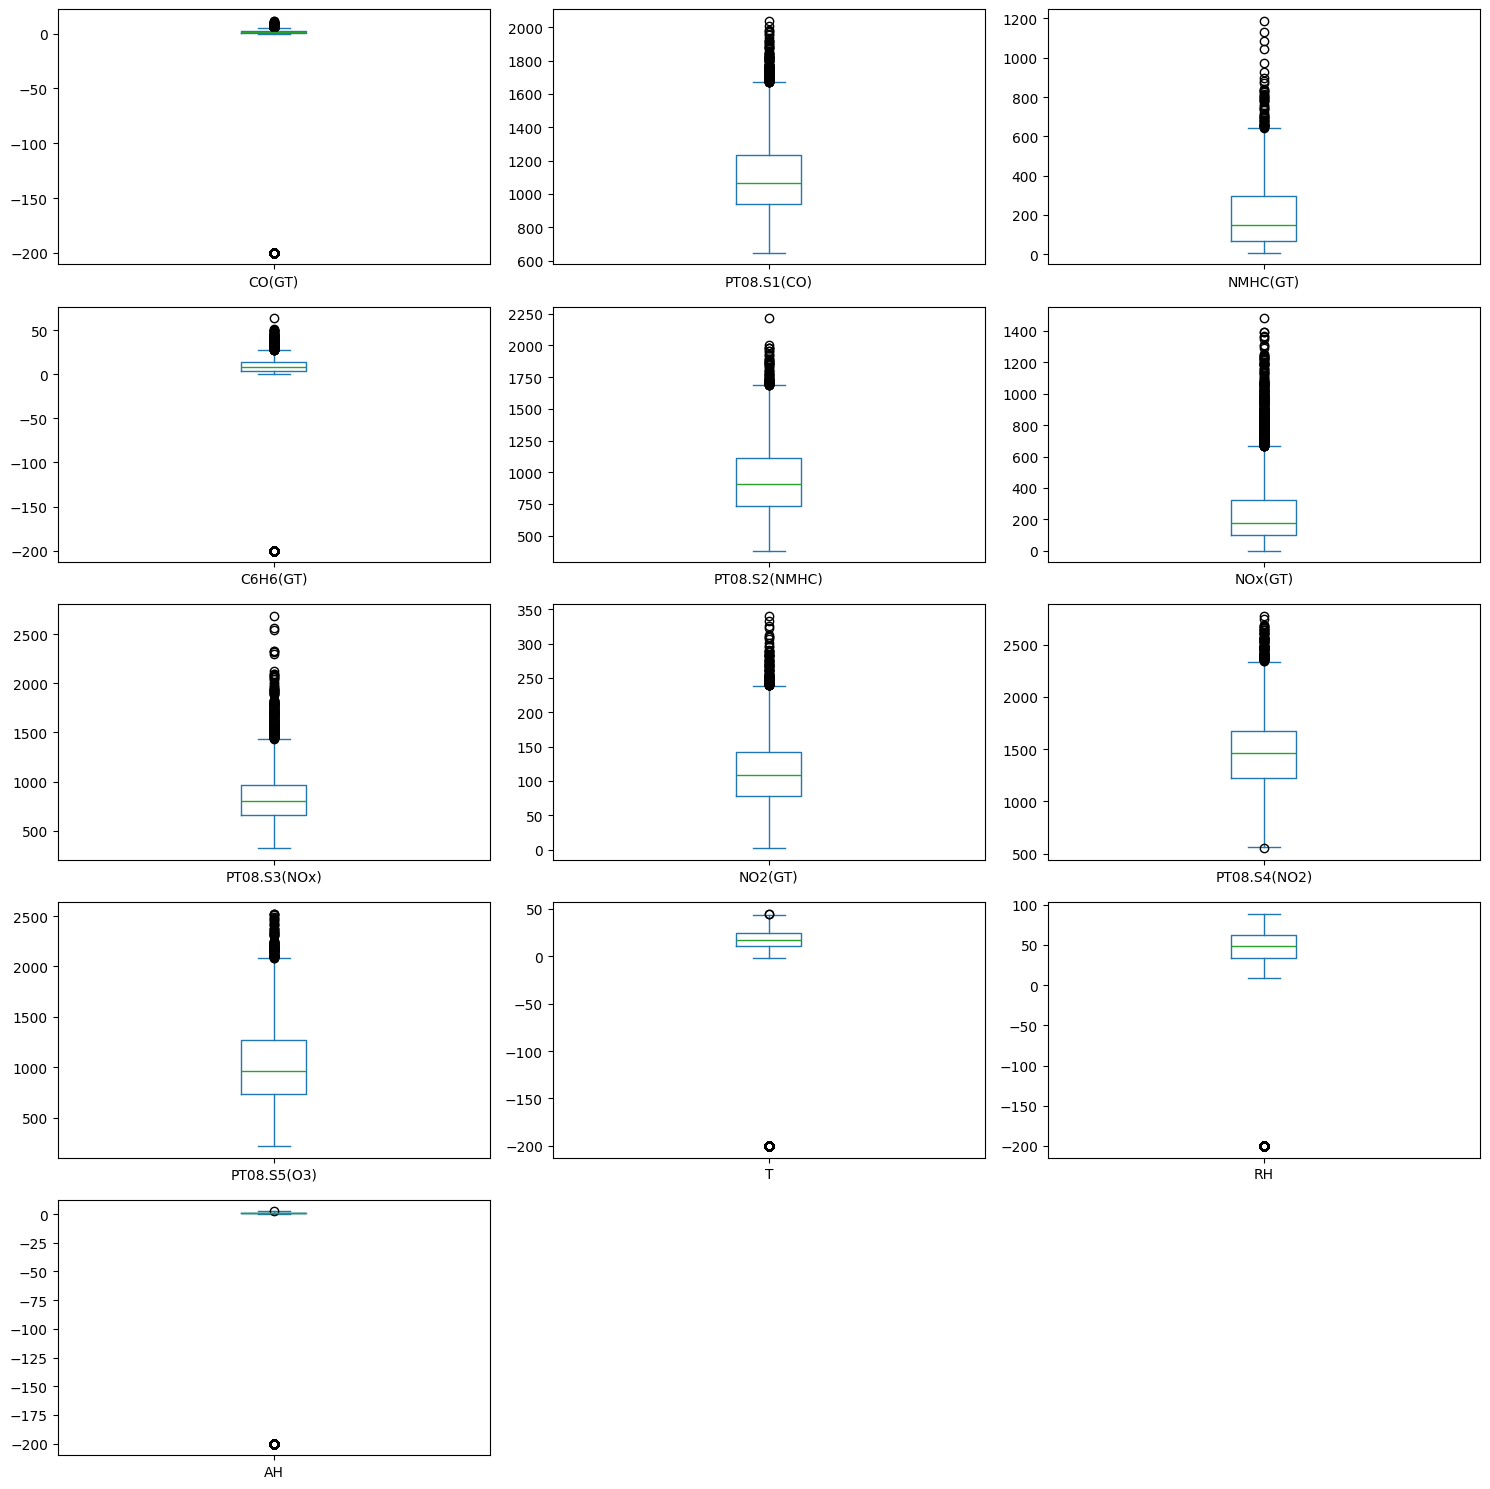

In [17]:
# Revisión de posibles valores atípicos
import matplotlib.pyplot as plt

df_num = df.select_dtypes(include='number')
df_num.plot(kind='box', subplots=True, layout=(5,3), figsize=(15,15))
plt.tight_layout()
plt.show()

**Observaciones:**
- Se observan valores atípicos en la mayoría de variables relacionadas con contaminantes.
- Algunas variables presentan gran dispersión, indicando un comportamiento no uniforme.
- Esto puede deberse a episodios de contaminación o errores de sensores.

# **3. Análisis univariado**

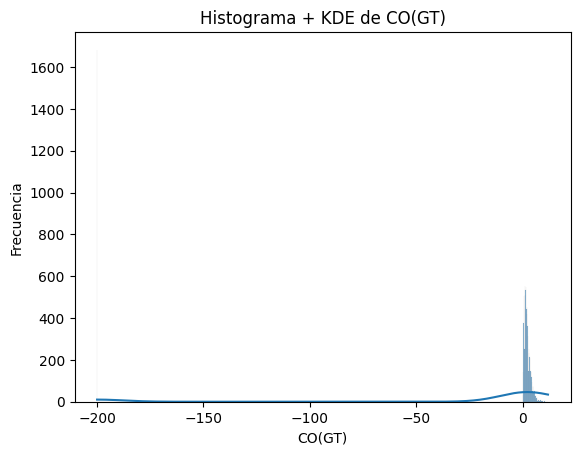

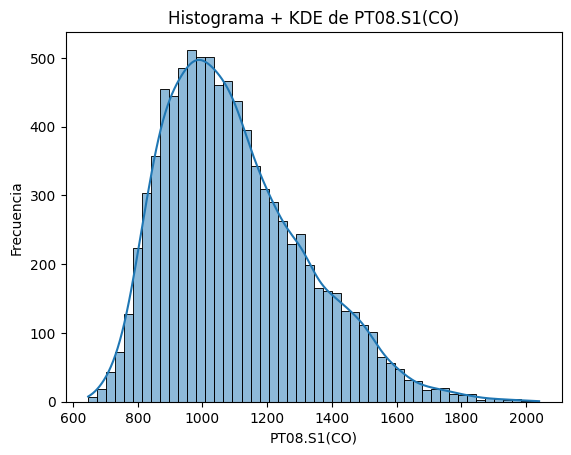

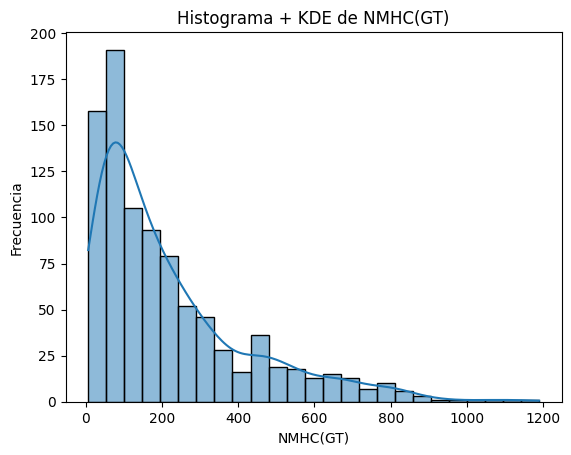

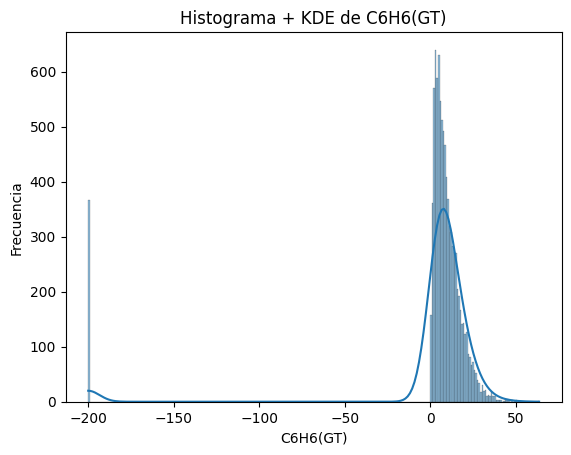

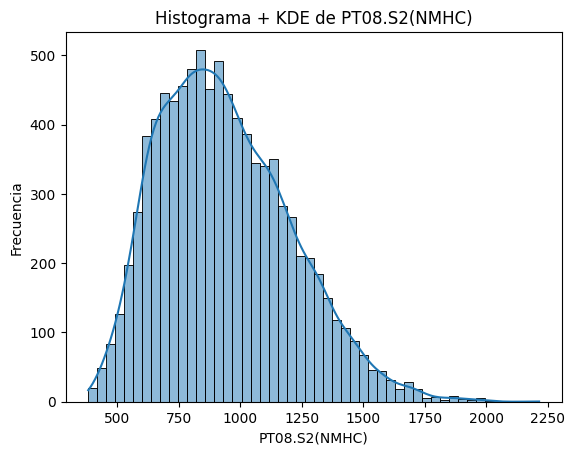

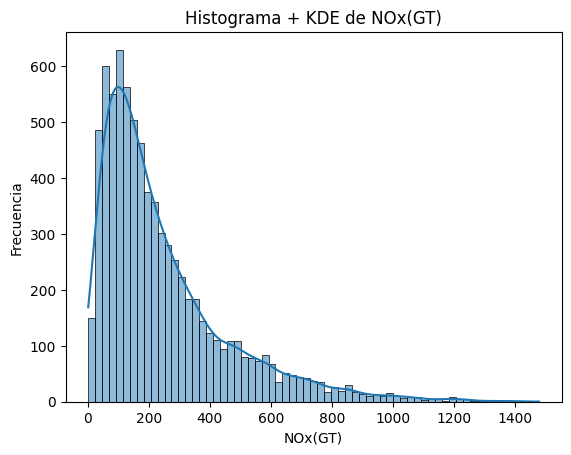

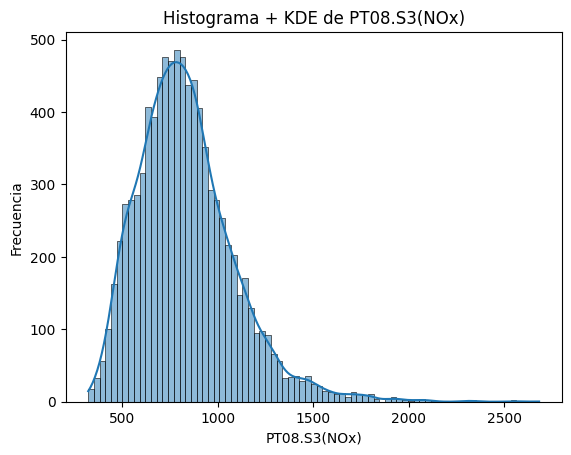

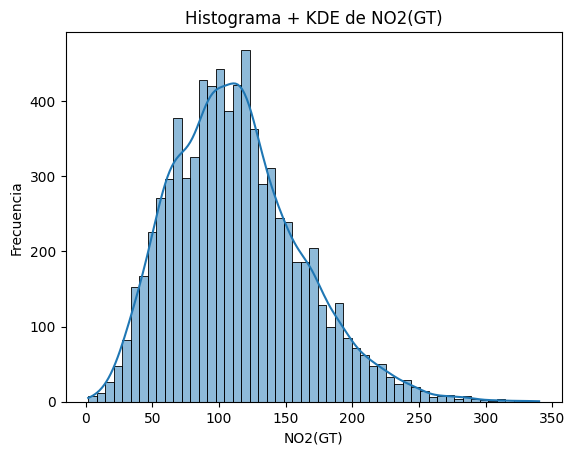

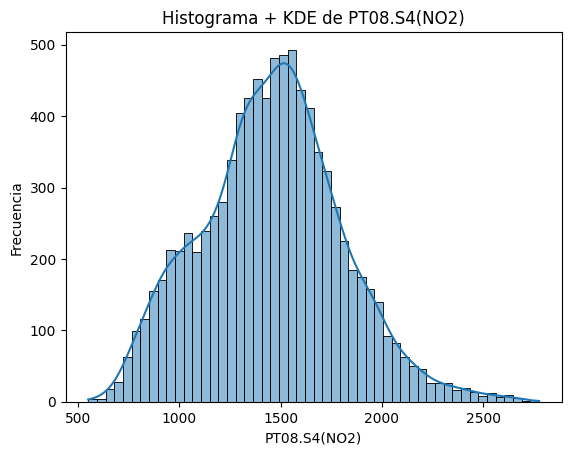

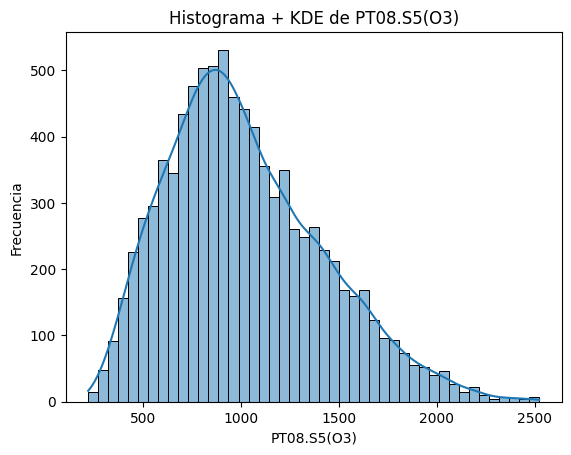

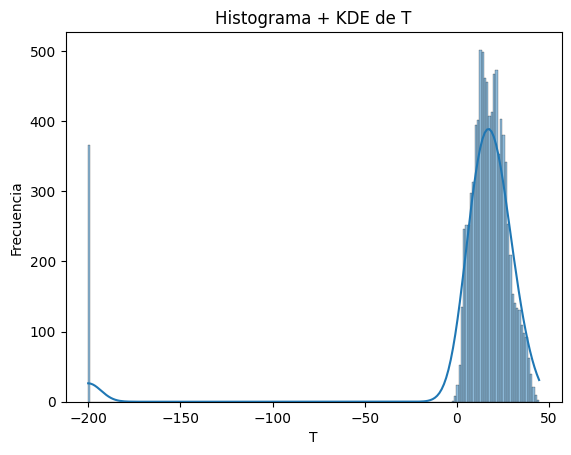

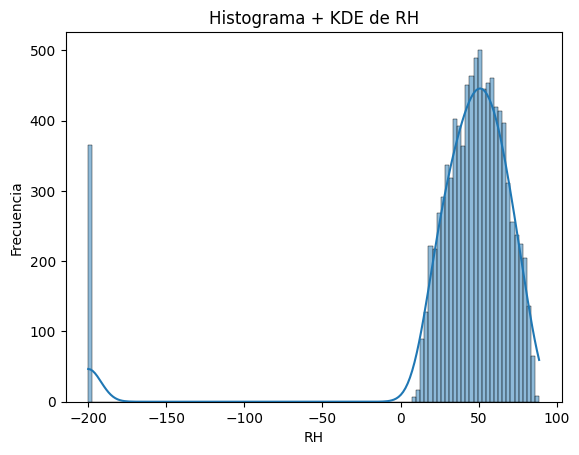

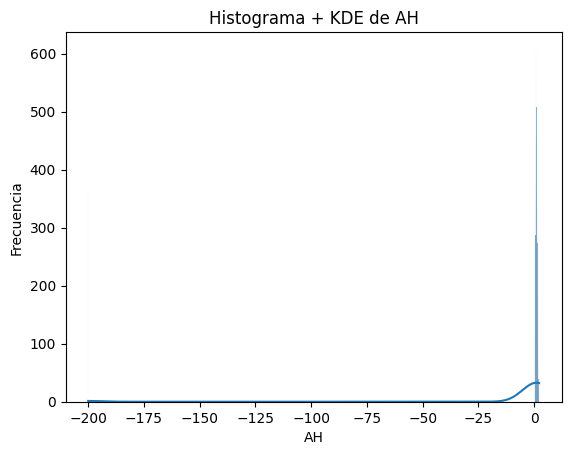

In [18]:
# Histograma + KDE para todas las variables numéricas
import matplotlib.pyplot as plt
import seaborn as sns

num_vars = df.select_dtypes(include='number').columns

for col in num_vars:

    plt.figure()
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Histograma + KDE de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

 **Observaciones:**
- La mayoría de las variables presentan distribuciones asimétricas positivas, con concentración de datos en los valores bajos.
- Se observan colas largas hacia valores altos, lo que indica episodios extremos de contaminación.
- Algunas variables muestran comportamiento cercano a normalidad, especialmente las variables meteorológicas.

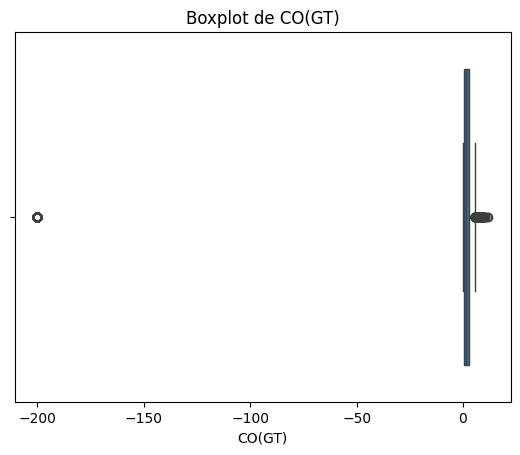

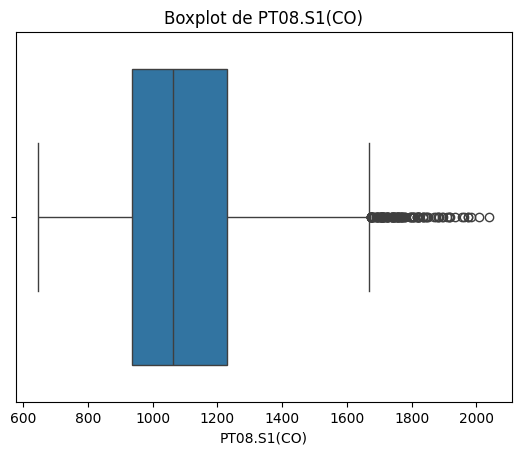

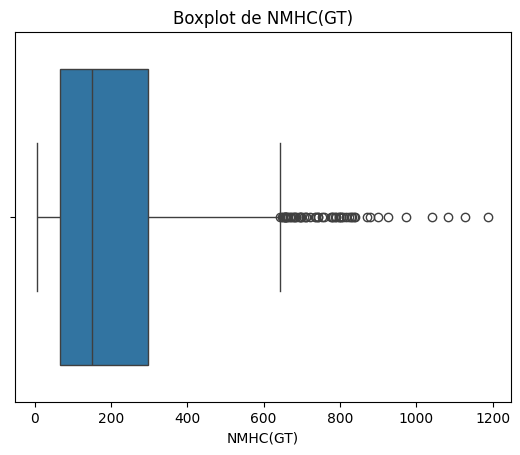

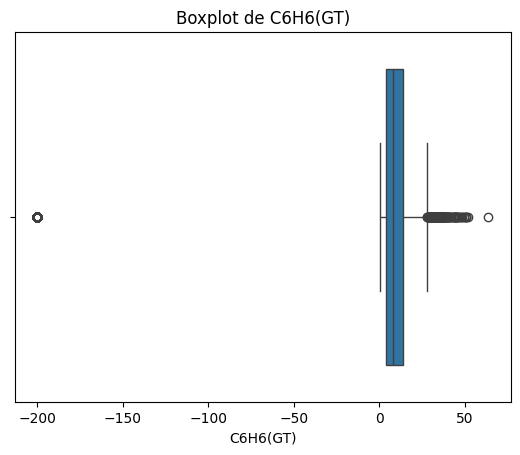

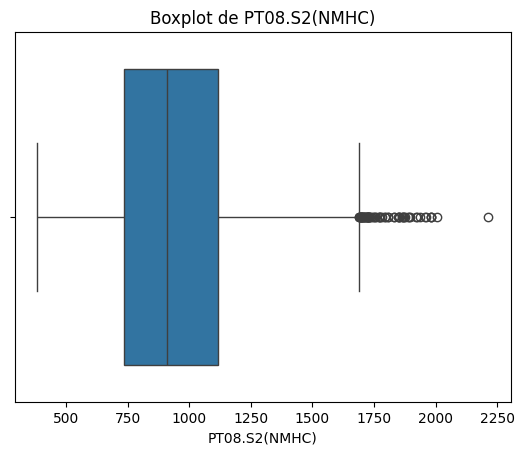

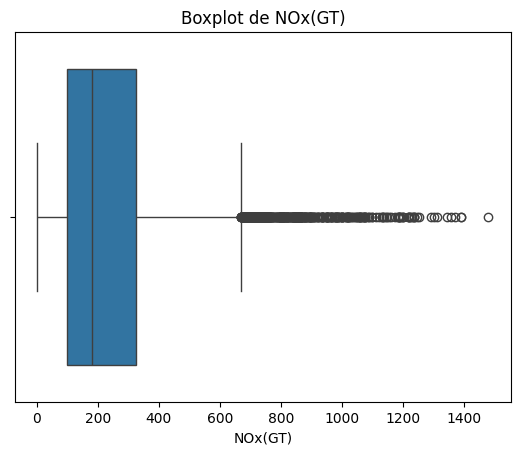

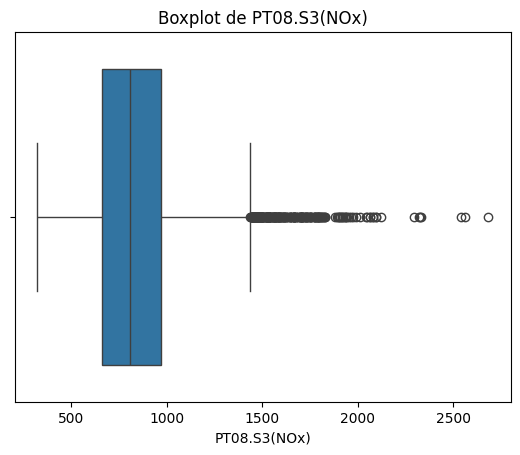

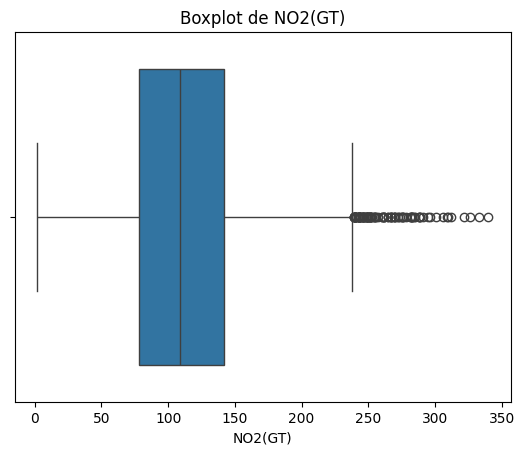

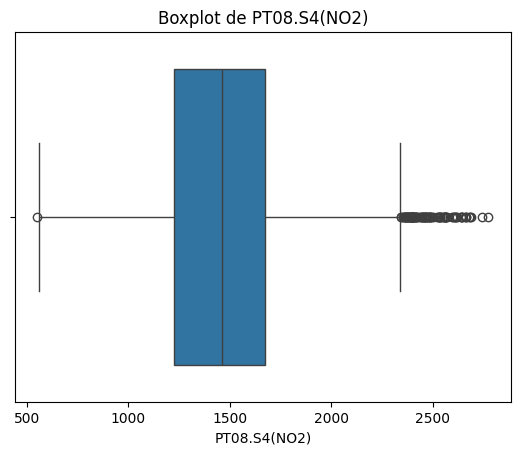

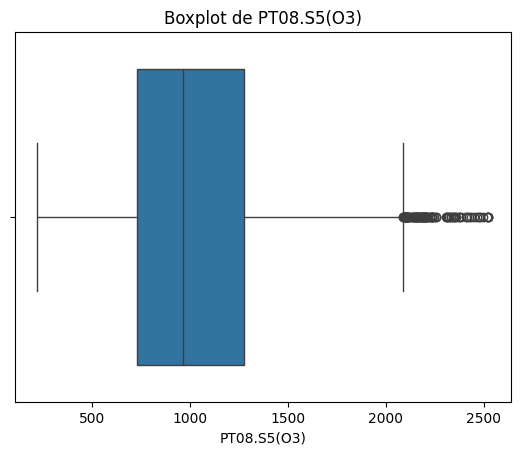

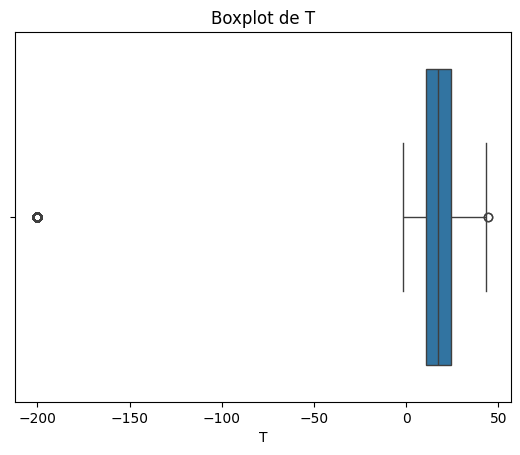

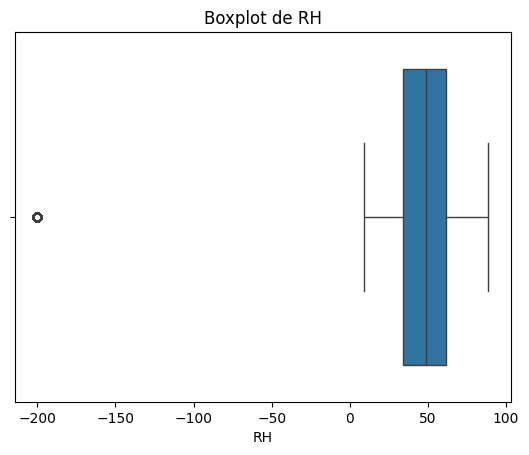

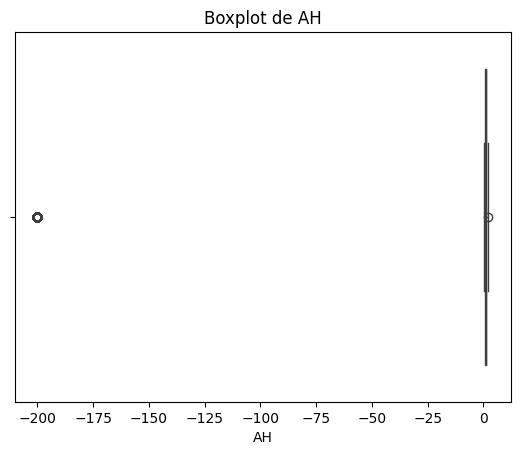

In [19]:
# Boxplot para todas las variables numéricas
for col in num_vars:

    plt.figure()
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot de {col}')
    plt.show()

**Observaciones:**
- Se detectan valores atípicos en varias variables, especialmente en los contaminantes.
- Este comportamiento sugiere una alta variabilidad ambiental o posibles errores de medición.
- Se observa que las variables meteorológicas presentan menor dispersión relativa.

# **4. Análisis bivariado**

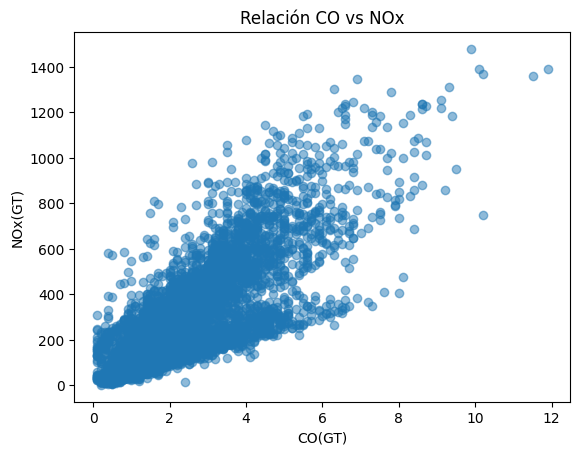

In [25]:
# Relación entre CO(GT) y NOx(GT)
import matplotlib.pyplot as plt

temp = df[['CO(GT)', 'NOx(GT)']].replace(-200, np.nan).dropna()

plt.figure()
plt.scatter(temp['CO(GT)'], temp['NOx(GT)'], alpha=0.5)
plt.xlabel('CO(GT)')
plt.ylabel('NOx(GT)')
plt.title('Relación CO vs NOx')
plt.show()

**Observaciones:**
- Se observa una tendencia positiva moderada.
- Cuando aumenta CO también tiende a aumentar NOx.
- Esto sugiere fuentes comunes de emisión.

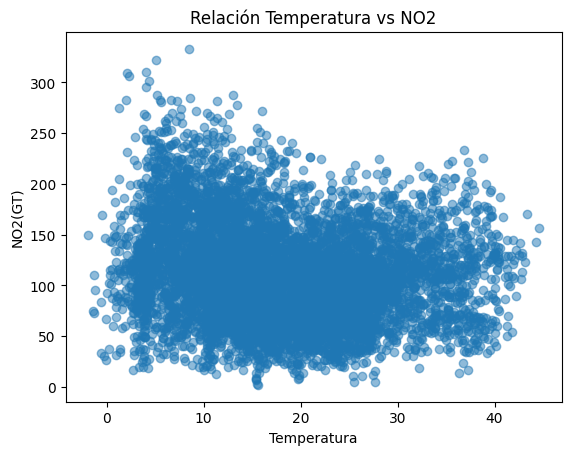

In [26]:
# Relación entre NO2(GT) y Temperatura (T)
temp = df[['T', 'NO2(GT)']].replace(-200, np.nan).dropna()

plt.figure()
plt.scatter(temp['T'], temp['NO2(GT)'], alpha=0.5)
plt.xlabel('Temperatura')
plt.ylabel('NO2(GT)')
plt.title('Relación Temperatura vs NO2')
plt.show()

**Observaciones:**
- Se observa dispersión alta, pero algunos picos de NO2 en ciertas temperaturas.
- Puede indicar efectos de reacciones fotoquímicas o condiciones atmosféricas.

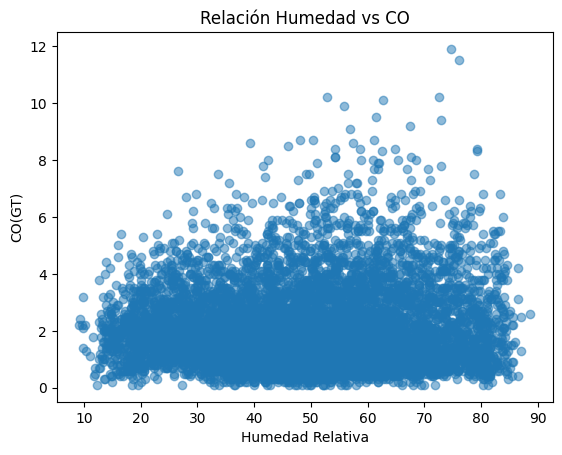

In [27]:
# Relación entre Humedad Relativa (RH) y CO(GT)
temp = df[['RH', 'CO(GT)']].replace(-200, np.nan).dropna()

plt.figure()
plt.scatter(temp['RH'], temp['CO(GT)'], alpha=0.5)
plt.xlabel('Humedad Relativa')
plt.ylabel('CO(GT)')
plt.title('Relación Humedad vs CO')
plt.show()

**Observaciones:**
- No se observa relación lineal clara.
- Sin embargo, algunos valores altos de CO coinciden con niveles específicos de humedad.

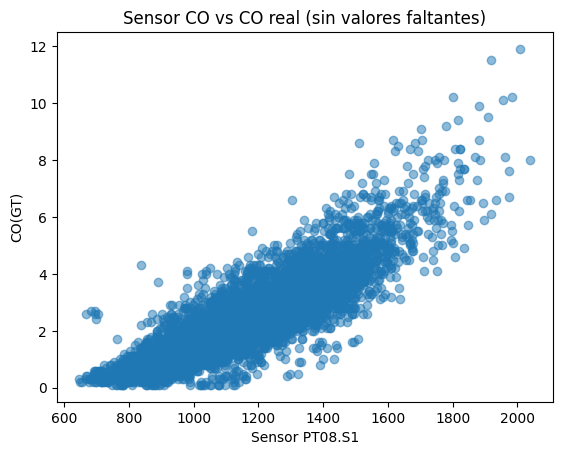

In [24]:
# Relación Sensor vs Concentración real
temp = df[['PT08.S1(CO)', 'CO(GT)']].replace(-200, np.nan).dropna()

plt.figure()
plt.scatter(temp['PT08.S1(CO)'], temp['CO(GT)'], alpha=0.5)
plt.xlabel('Sensor PT08.S1')
plt.ylabel('CO(GT)')
plt.title('Sensor CO vs CO real (sin valores faltantes)')
plt.show()

**Observaciones:**
- Se observa relación positiva clara.
- Esto indica que el sensor tiene capacidad predictiva sobre la concentración real.

# **5. Análisis multivariado**

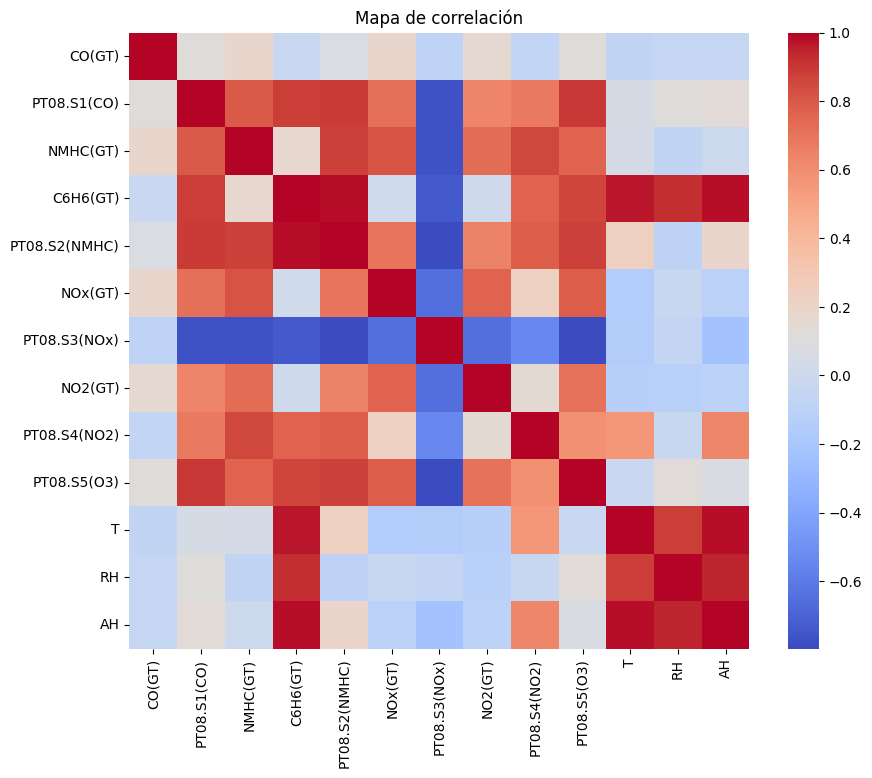

In [29]:
# Mapa de Calor - Correlación entre variables numéricas
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Mapa de correlación')
plt.show()

**Observaciones:**
- Alta correlación entre sensores químicos
- Variables meteorológicas correlacionadas entre sí
- Algunos sensores presentan correlación negativa con NOx

# **6. Identificación de patrones**

- **¿Qué patrones importantes encontraste?**

  - Las concentraciones de contaminantes muestran observaciones extremas
  - Los sensores tienen fuerte relación entre ellos

- **¿Existen relaciones entre variables?**

  - Existe una relación positiva entre CO y NO2
  - Se encontró una correlación fuerte entre temperatura y humedad

- **¿Se observan clusters naturales?**

  - Sí, en los gráficos de dispersión se distinguen dos grupos principales: Valores bajos normales y observaciones de alta contaminación

- **¿Existen outliers?**

  - Sí, sobre todo en NO2 y NOx

- **¿Qué variables parecen ser más relevantes?**

  - CO(GT)
  - NO2(GT)
  - PT08.S1(CO)
  - PT08.S4(NO2)
  - Temperatura y humedad como variables explicativas
